### P-Median Optimization of Affordable Housing Developments in Cook County Based on Gentrification Risk Assessment 

**Project Goal:** Use p-median to optimize placement of 10 potential affordable housing developments in Cook County based on gentrification vulnerability (analyzed through percentage of renters and median income) along with property sale prices from 2023-2025.


In [86]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

My initial data used is all from the Cook County Assessor's Office. The neighborhoods dataset is a geojson file that includes all boundaries for neighborhoods defined by the Asessor intended to group together homogenous housinng markets. The sales dataset includes all parcel sales from 2023-2025 in Cook County, including the neighborhood it was sold in, the price, the date, and more.

With these two datasets, I performed inverse distance weighting (IDW) to analyze property sales prices and to get a preliminary look at the overall predicted trends throughout Cook County.

Calculating IDW...


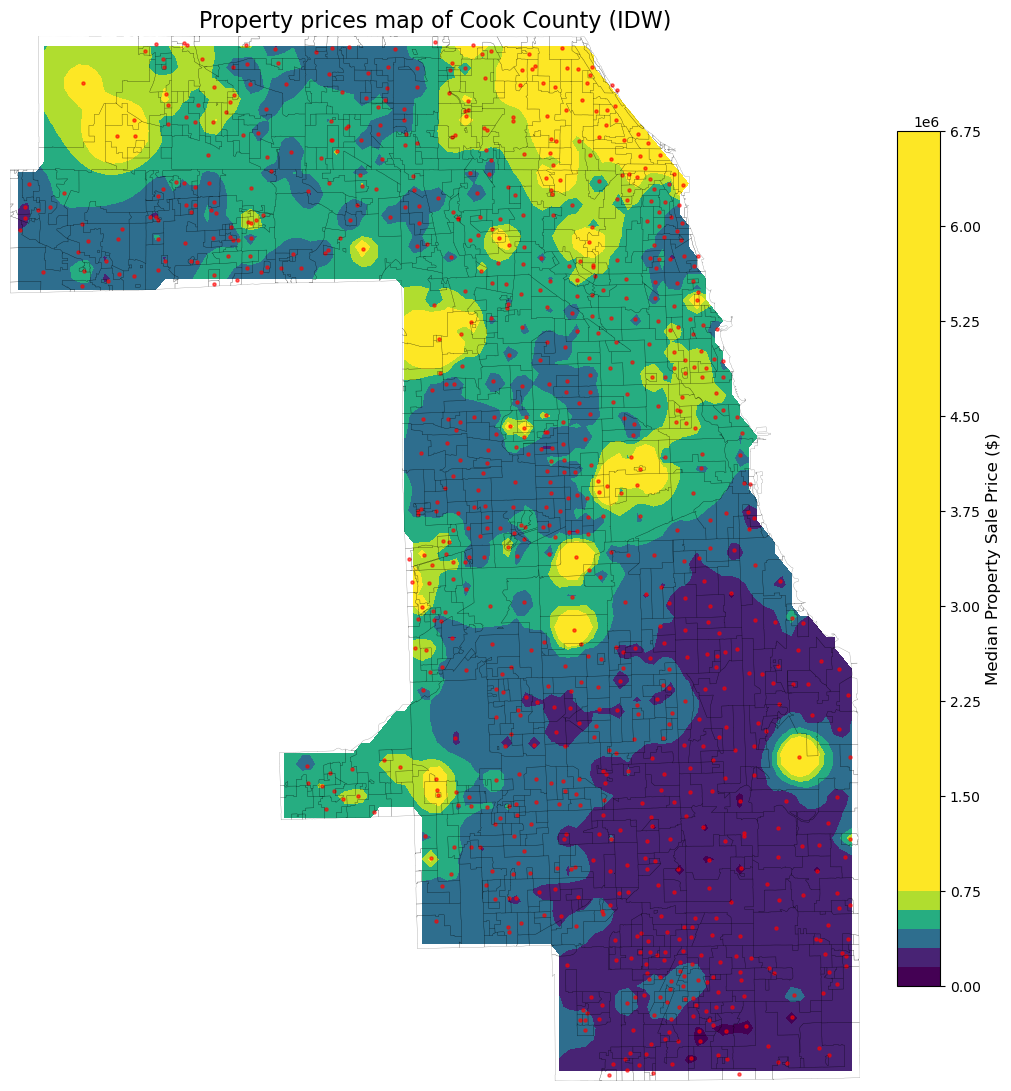

In [87]:
import numpy as np
from scipy.spatial.distance import cdist
from shapely.geometry import Point

nbhds = gpd.read_file('Assessor_-_Neighborhood_Boundaries_20260424.geojson')
sales = pd.read_csv('Assessor_-_Parcel_Sales_20260424.csv', low_memory=False)

#cleaning
sales['sale_price'] = sales['sale_price'].replace('[\$,]', '', regex=True).astype(float)
nbhds['town_nbhd'] = nbhds['town_nbhd'].astype(str).str.strip()
sales['neighborhood_code'] = sales['neighborhood_code'].astype(str).str.strip()

#aggregate by nbhd
nbhd_stats = sales.groupby('neighborhood_code')['sale_price'].median().reset_index()
gdf_sites = nbhds.merge(nbhd_stats, left_on='town_nbhd', right_on='neighborhood_code')
gdf_sites = gdf_sites.to_crs(epsg=3435).dropna(subset=['sale_price'])

#centroids
x_sites = gdf_sites.geometry.centroid.x.values
y_sites = gdf_sites.geometry.centroid.y.values
sites_coords = np.column_stack([x_sites, y_sites])
z_values = gdf_sites.sale_price.values

#grid
res = 100 
chicago_gdf = nbhds.to_crs(epsg=3435)
xmin, ymin, xmax, ymax = chicago_gdf.total_bounds
grid_x, grid_y = np.meshgrid(np.linspace(xmin, xmax, res), np.linspace(ymin, ymax, res))
grid_coords = np.column_stack([grid_x.ravel(), grid_y.ravel()])

print("Calculating IDW...")
p = 2
dist_matrix = cdist(grid_coords, sites_coords)
dist_matrix = np.where(dist_matrix == 0, 1e-10, dist_matrix)
weights = 1 / (dist_matrix**p)
z_star = np.sum(weights * z_values, axis=1) / np.sum(weights, axis=1)
z_grid = z_star.reshape(res, res)

#clamp
chicago_shape = chicago_gdf.unary_union
mask = np.array([chicago_shape.contains(Point(x, y)) for x, y in grid_coords]).reshape(res, res)
z_grid[~mask] = np.nan 

#plot
fig, ax = plt.subplots(figsize=(12, 15))
vmin, vmax = np.percentile(z_values, 10), np.percentile(z_values, 90)

#background
im = ax.contourf(grid_x, grid_y, z_grid, levels=50, cmap='viridis', vmin=vmin, vmax=vmax)

#boundaries + red points
chicago_gdf.boundary.plot(ax=ax, color='black', linewidth=0.2, alpha=0.5)
ax.scatter(x_sites, y_sites, color='red', s=5, alpha=0.6, label='Neighborhood Centroids')

#legend
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Median Property Sale Price ($)', fontsize=12)
plt.title("Property prices map of Cook County (IDW)", fontsize=16)
ax.set_axis_off()
plt.show()

Next, I wanted to take a simple overview at the percentage of renters as well as the median household income throughout Cook County through chloropleth maps. It's a great way to get a look at the data I'm going to be using to choose the ten potential site locations.

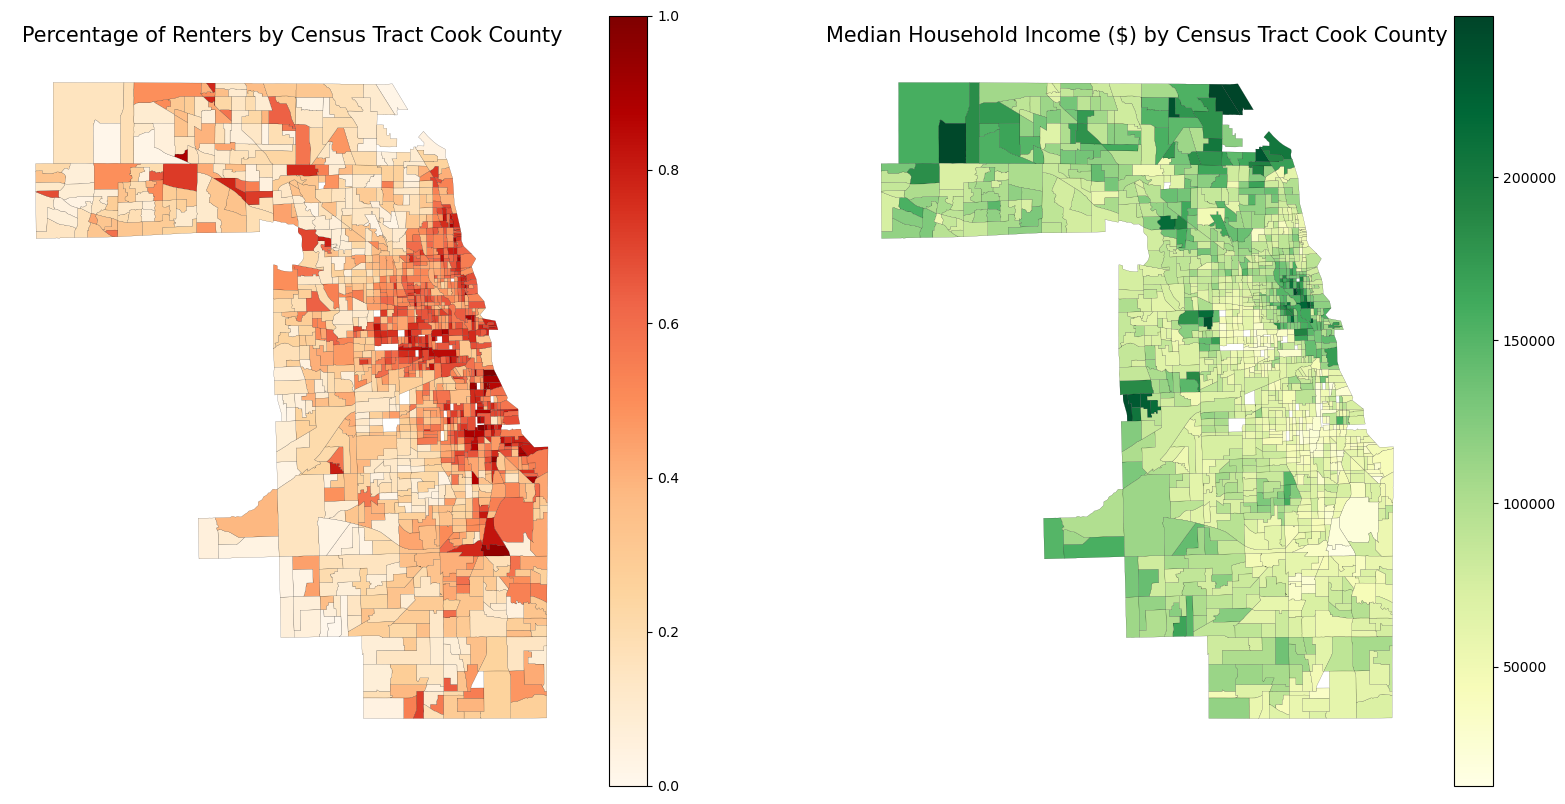

In [88]:
tenure_df = pd.read_csv('ACS_Tenure_Data.csv', skiprows=1) 
income_df = pd.read_csv('ACS_Median_Income_Data.csv', skiprows=1)
census_df = pd.merge(tenure_df, income_df, on='Geography')
census_df['GEOID'] = census_df['Geography'].str.slice(start=-11)

#variables
census_df['percent_renters'] = census_df['Estimate!!Total:!!Renter occupied'] / census_df['Estimate!!Total:']
income_col = 'Estimate!!Median household income in the past 12 months (in 2024 inflation-adjusted dollars)'
census_df['median_income'] = pd.to_numeric(census_df[income_col], errors='coerce')

#drop nulls
census_df = census_df[['GEOID', 'percent_renters', 'median_income']].dropna()

#shapefiles, attach demographics
tracts_gdf = gpd.read_file('tl_2024_17_tract.shp')
cook_tracts_gdf = tracts_gdf[tracts_gdf['COUNTYFP'] == '031']
final_tracts_gdf = cook_tracts_gdf.merge(census_df, on='GEOID', how='inner')

#plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

final_tracts_gdf.plot(column='percent_renters', cmap='OrRd', legend=True, 
                      edgecolor='black', linewidth=0.1, ax=ax1)
ax1.set_title("Percentage of Renters by Census Tract Cook County", fontsize=15)
ax1.set_axis_off()

final_tracts_gdf.plot(column='median_income', cmap='YlGn', legend=True, 
                      edgecolor='black', linewidth=0.1, ax=ax2)
ax2.set_title("Median Household Income ($) by Census Tract Cook County", fontsize=15)
ax2.set_axis_off()
plt.show()

Looking at the two chloropleth maps, we can see some trends in where we see higher percentages of renters and where income is on the lower side.

Next, I joined all of the datasets into one dataset aligned by Cook County Assessor neighborhoods.

With all of our data together now, I calculated the gentrification vulnerability score as:
$$\text{Vulnerability Score} = \frac{\text{Renters}}{\text{Income} \times \text{Home Price}} \times 10^{10}$$

The formula highlights where displacement risk is highest (more renters) and financial barriers are lowest (lower income and property sale prices), attempting to find exactly where gentrificaton is most likely to occur and push people out.


In [89]:
#align
final_tracts_gdf = final_tracts_gdf.to_crs(epsg=3435)

#centroids
demand_nodes = gdf_sites
demand_nodes['geometry'] = demand_nodes.geometry.centroid

#SPATIAL JOIN
joined_nodes = gpd.sjoin(demand_nodes, final_tracts_gdf, how="inner", predicate="within")

#Vulnerability Score (Demand Weight)
#(Renters) / (Income * Home Price) * 10^10 so nums readable
joined_nodes['demand_weight'] = (joined_nodes['percent_renters'] * 1e10) / (joined_nodes['median_income'] * joined_nodes['sale_price'])

#clean up
model_data = joined_nodes[['neighborhood_code', 'demand_weight', 'geometry']]
print(f"Total neighborhoods ready for optimization: {len(model_data)}")
model_data.head()

Total neighborhoods ready for optimization: 836


,neighborhood_code,demand_weight,geometry
0,31041,0.174946,POINT (1113724.299 1908076.691)
1,31040,0.082346,POINT (1119018.675 1903925.614)
2,31034,0.275283,POINT (1115755.948 1894703.031)
3,31033,0.215786,POINT (1113651.296 1886673.984)
6,31030,0.247722,POINT (1114599.120 1890777.444)


With the gentrification vulnerability scores calculated, I wanted to look at the overall distribution of at risk neighborhoods throughout Cook County through another simple chloropleth map.

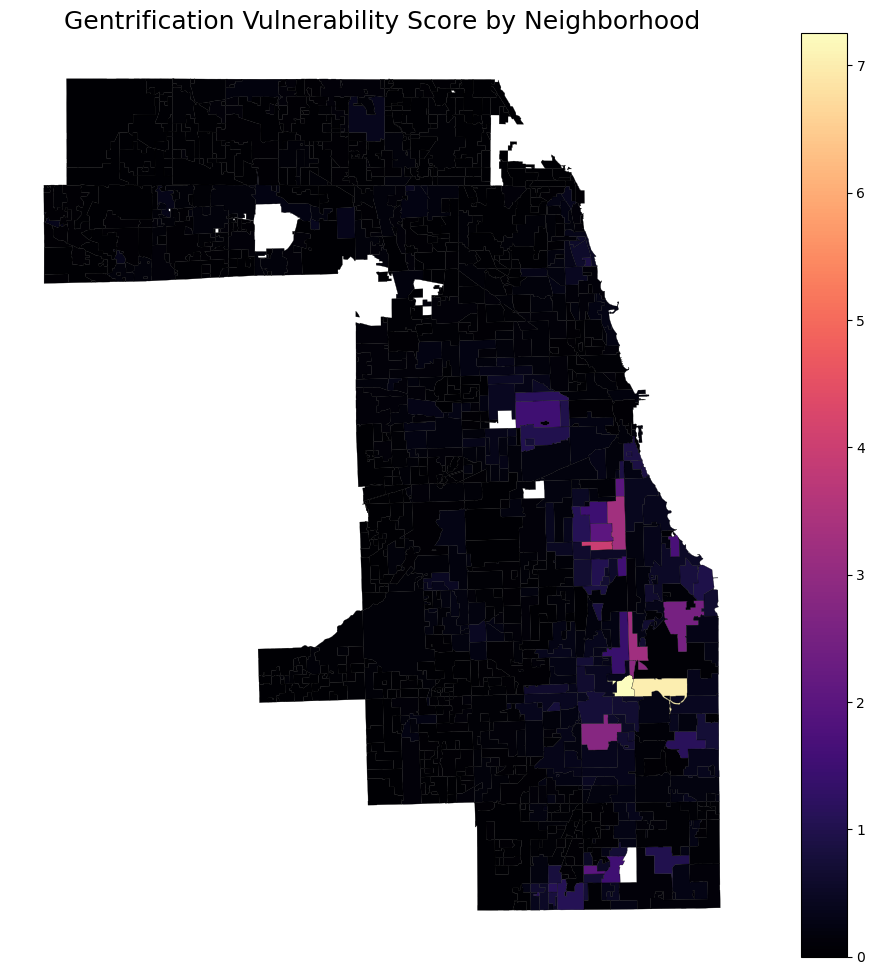

In [90]:
#merge weights and neighborhoods
vuln_map_gdf = chicago_gdf.merge(model_data[['neighborhood_code', 'demand_weight']], 
                                 left_on='town_nbhd', right_on='neighborhood_code', how='inner')

fig, ax = plt.subplots(figsize=(12, 12))
vuln_map_gdf.plot(column='demand_weight', cmap='magma', legend=True, 
                  edgecolor='black', linewidth=0.2, ax=ax)
plt.title("Gentrification Vulnerability Score by Neighborhood", fontsize=18)
ax.set_axis_off()
plt.show()

Since we have 836 neighborhoods in Cook County as defined by the Cook County Assessor's Office and solving p-median takes an exponentially longer time to find an optimal solution the more neighborhoods present, I decided to aggregate Cook County into 200 clusters. I did this using K-means clustering.

In [91]:
from sklearn.cluster import KMeans

#836 -> 200
num_zones = 200
coords = np.array([(geom.x, geom.y) for geom in model_data.geometry])
kmeans = KMeans(n_clusters=num_zones, random_state=42, n_init=10)
model_data.loc[:, 'zone'] = kmeans.fit_predict(coords)

#combine weights
zone_weights = model_data.groupby('zone')['demand_weight'].sum().to_dict()
zone_coords = kmeans.cluster_centers_

#new variable
nodes = list(range(num_zones))
weights = zone_weights
coords = zone_coords

print(f"Reduced from 836 neighborhoods to {num_zones} zones")

Reduced from 836 neighborhoods to 200 zones


/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.4/lib/python3.8/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


With 200 zones to pick from now, I defined our candidate locations and ran the p-median optimization model to find the 10 potential sites that minimize the overall demand-weighted distance ensuring affordable housing developments are placed in the most accessible high-need areas based on gentrification threats.

In [92]:
import pulp

nodes = list(range(200))
weights = zone_weights
coords = zone_coords
print(f"{len(nodes)} zones")

dist_matrix = cdist(coords, coords)
distances = {}
for i, origin in enumerate(nodes):
    distances[origin] = {}
    for j, dest in enumerate(nodes):
        distances[origin][dest] = dist_matrix[i][j]

p = 10
prob = pulp.LpProblem("PMedian_Housing", pulp.LpMinimize)
y = pulp.LpVariable.dicts("Facility", nodes, 0, 1, pulp.LpBinary)
x = pulp.LpVariable.dicts("Assignment", (nodes, nodes), 0, 1, pulp.LpBinary)

prob += pulp.lpSum(weights[i] * distances[i][j] * x[i][j] for i in nodes for j in nodes)
prob += pulp.lpSum(y[j] for j in nodes) == p

for i in nodes:
    prob += pulp.lpSum(x[i][j] for j in nodes) == 1
    for j in nodes:
        prob += x[i][j] <= y[j]

print("Handing off to pulp")
prob.solve()
print("Solver finished")

print("--- RESULTS ---")
print("Status:", pulp.LpStatus[prob.status])

chosen_facilities = [j for j in nodes if y[j].varValue == 1.0]
print(f"Optimal Zones for Affordable Housing: {chosen_facilities}")

200 zones
Handing off to pulp
GLPSOL: GLPK LP/MIP Solver, v4.65
Parameter(s) specified in the command line:
 --cpxlp /tmp/ccaad1aa2dee479199592268d3b570c0-pulp.lp -o /tmp/ccaad1aa2dee479199592268d3b570c0-pulp.sol
Reading problem data from '/tmp/ccaad1aa2dee479199592268d3b570c0-pulp.lp'...
40201 rows, 40200 columns, 120200 non-zeros
40200 integer variables, all of which are binary
112745 lines were read
GLPK Integer Optimizer, v4.65
40201 rows, 40200 columns, 120200 non-zeros
40200 integer variables, all of which are binary
Preprocessing...
40201 rows, 40200 columns, 120200 non-zeros
40200 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 40201
Solving LP relaxation...
GLPK Simplex Optimizer, v4.65
40201 rows, 40200 columns, 120200 non-zeros
      0: obj =   0.000000000e+00 inf =   2.080e+02 (200)
    199: obj =   1.5436030

Our 10 optimal zones for affordable housing are zones:
11, 27, 50, 76, 87, 113, 122, 140, 180, and 191.

Cook County should look into building affordable housing centers in these 10 zones.

Next, I made a map showing where the housing centers would potentially be placed and what zones the centers would be designed to help individuals be eliviated from gentrificaiton pressures.

The centers are plotted as stars and the links are plotted as lines. The background highlights our original neighborhoods and their respective gentrification vulnerablity score.

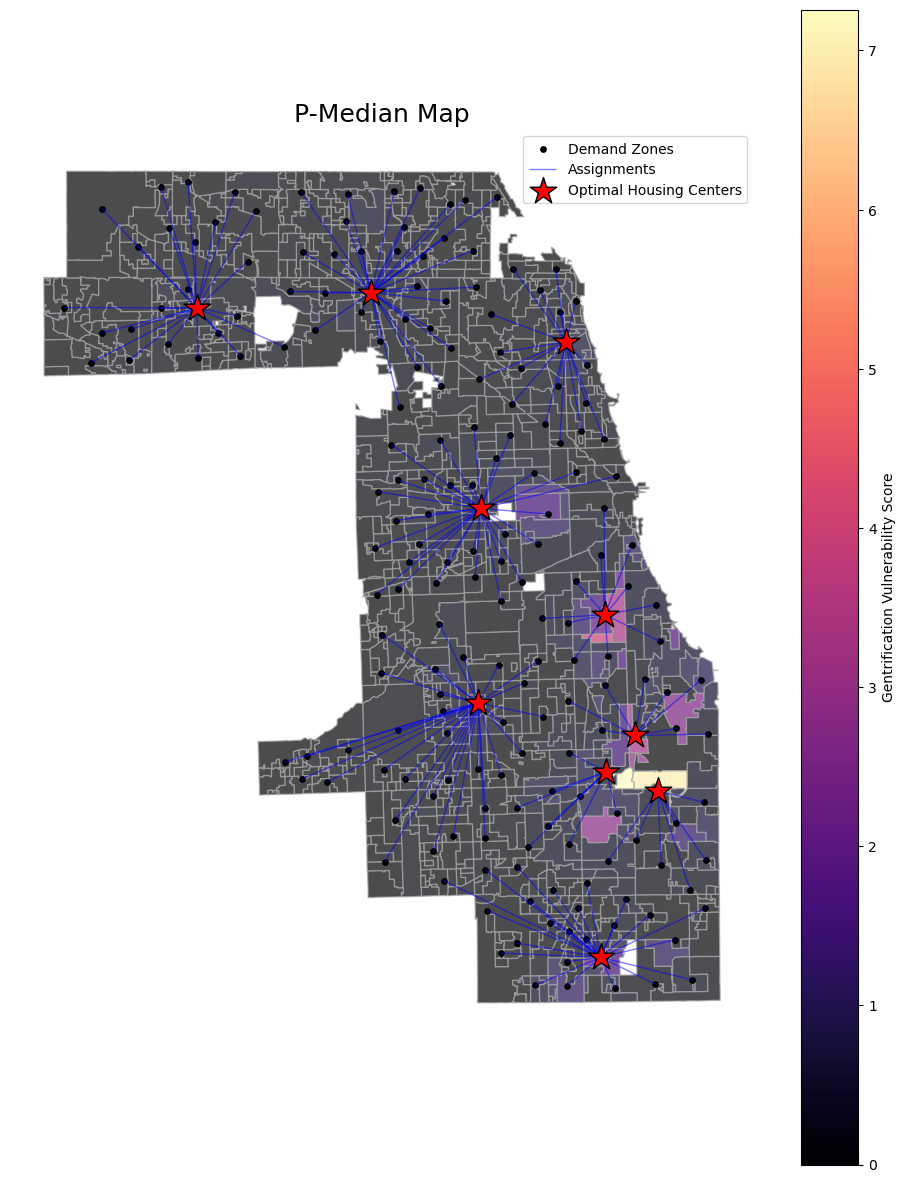

In [93]:
from shapely.geometry import LineString

cols_to_drop = ['demand_weight', 'neighborhood_code', 'demand_weight_x', 'neighborhood_code_x']
chicago_gdf = chicago_gdf.drop(columns=[c for c in cols_to_drop if c in chicago_gdf.columns])

chicago_gdf = chicago_gdf.merge(model_data[['neighborhood_code', 'demand_weight']], 
                                 left_on='town_nbhd', right_on='neighborhood_code', how='left')

#gdf for centers
optimal_points = [Point(coords[j]) for j in chosen_facilities]
optimal_gdf = gpd.GeoDataFrame({'node_id': chosen_facilities}, geometry=optimal_points, crs="EPSG:3435")
joined_facilities = gpd.sjoin(optimal_gdf, chicago_gdf, how="left", predicate="within")

lines = []
for i in nodes:
    for j in nodes:
        # Check if the solver decided to assign zone i to facility j
        if x[i][j].varValue == 1.0:
            line = LineString([coords[i], coords[j]])
            lines.append(line)

#convert lines
gdf_lines = gpd.GeoDataFrame(geometry=lines, crs="EPSG:3435")

fig, ax = plt.subplots(figsize=(12, 15))

#background
chicago_gdf.plot(ax=ax, column='demand_weight', cmap='magma', edgecolor='darkgrey', alpha=0.7, legend=True, legend_kwds={'label': "Gentrification Vulnerability Score", 'orientation': "vertical"})

#black node demand zones
x_nodes = [c[0] for c in coords]
y_nodes = [c[1] for c in coords]
ax.scatter(x_nodes, y_nodes, color='black', s=15, zorder=3, label='Demand Zones')

gdf_lines.plot(ax=ax, color='blue', linewidth=1, alpha=0.5, zorder=4, label='Assignments')

#optimal locatons
ax.scatter(joined_facilities.geometry.x, joined_facilities.geometry.y, color='red', marker='*', s=400, 
           edgecolor='black', zorder=5, label='Optimal Housing Centers')

plt.title("P-Median Map", fontsize=18)
ax.set_axis_off()
plt.legend()
plt.show()

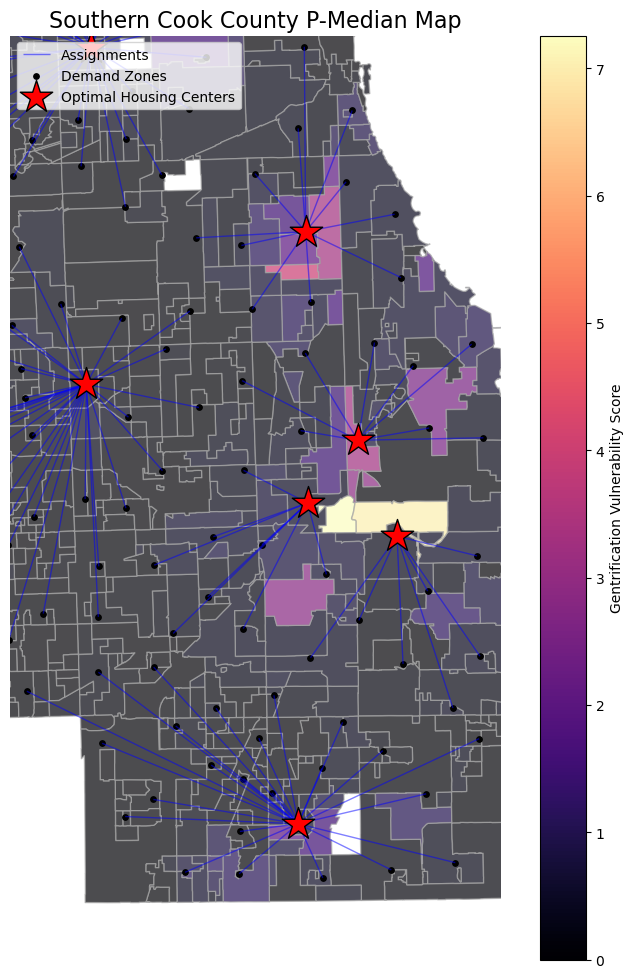

In [107]:
fig, ax = plt.subplots(figsize=(10, 12))

chicago_gdf.plot(ax=ax, column='demand_weight', cmap='magma', 
                edgecolor='darkgrey', alpha=0.7, legend=True, legend_kwds={'label': "Gentrification Vulnerability Score", 'orientation': "vertical"})
gdf_lines.plot(ax=ax, color='blue', linewidth=1, alpha=0.5, 
              zorder=4, label='Assignments')
ax.scatter([c[0] for c in coords], [c[1] for c in coords], 
           color='black', s=15, zorder=3, label='Demand Zones')
ax.scatter(joined_facilities.geometry.x, joined_facilities.geometry.y, 
           color='red', marker='*', s=600, edgecolor='black', 
           zorder=5, label='Optimal Housing Centers')

#South limits
ax.set_xlim(1120000, 1205000)
ax.set_ylim(1740000, 1900000)
plt.title("Southern Cook County P-Median Map", fontsize=16)
ax.set_axis_off()
plt.legend(loc='upper left')
plt.show()

While we see an even spread of facilities across the county, there is a strong concentration of facilities on the South side of Chicago as well as into the Calumet and Thornton area further South.

This aligns with what I expected because these areas are the ones with the highest gentrification vulnerability based on high percentage of renters, low median income, and low property sale prices.

In [100]:
# 1. Convert the CRS to WGS84 (Standard Latitude/Longitude)
centers_wgs84 = joined_facilities.to_crs(epsg=4326)

# 2. Extract Latitude and Longitude from the geometry
centers_wgs84['Latitude'] = centers_wgs84.geometry.y
centers_wgs84['Longitude'] = centers_wgs84.geometry.x

# 3. Create the final clean display table
# We use node_id and demand_weight based on your previous dataframe columns
final_coords = centers_wgs84[['node_id', 'town_nbhd', 'demand_weight', 'Latitude', 'Longitude']].copy()
final_coords.columns = ['Center ID', 'Neighborhood', 'Vulnerability Score', 'Latitude', 'Longitude']

display(final_coords)

,Center ID,Neighborhood,Vulnerability Score,Latitude,Longitude
0,11,39040,0.214427,41.716101,-87.787710
1,27,75022,0.337661,42.012415,-87.688549
2,50,22031,0.074728,42.054015,-87.902725
3,76,12085,0.507583,41.506513,-87.655510
4,87,14030,0.430293,41.658968,-87.647996
5,113,27080,0.031013,41.876070,-87.783204
6,122,35020,0.161004,42.041840,-88.095208
7,140,70210,3.241815,41.688527,-87.615793
8,180,72091,1.502276,41.787868,-87.647841
9,191,37021,0.265737,41.642796,-87.591482


My model provides a blueprint for affordable housing center development in Cook County. The concentration of facilities in the South Side of Chicago and the Calumet-Thornton area addresses the high intensity of poverty and gentrification displacement risk, while the wider distribution across the county ensures that accessibility isn't sacrified for other residents in high-need pockets. This approach tackles both the more immediate crisis of gentrification and long term county wide equity.